# Лабораторная работа №1: Первичное исследование и оценка качества данных

**Дисциплина:** Интеллектуальный анализ данных  
**Датасет:** TV Shows Dataset (tv_shows.csv)  
**Цель:** первично описать структуру данных, оценить качество (пропуски/дубликаты/аномалии) и выполнить мини-EDA.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

PATH = "../data/tv_shows.csv"

df = pd.read_csv(PATH)

# Удаляем лишний индексный столбец
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df.head()

,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,type
0,Breaking Bad,2008,18+,9.5,96%,1,0,0,0,1
1,Stranger Things,2016,16+,8.8,93%,1,0,0,0,1
2,Money Heist,2017,18+,8.4,91%,1,0,0,0,1
3,Sherlock,2010,16+,9.1,78%,1,0,0,0,1
4,Better Call Saul,2015,18+,8.7,97%,1,0,0,0,1


## 1. Постановка задачи (Business Understanding)

**Что это за данные.**  
Датасет содержит информацию о 5611 телевизионных шоу. Каждая строка соответствует одному шоу и содержит: название, год выпуска, возрастной рейтинг, рейтинги IMDb и Rotten Tomatoes, а также информацию о доступности на стриминговых платформах (Netflix, Hulu, Prime Video, Disney+).  
Данные позволяют изучить, как распределены шоу по годам, возрастным категориям и платформам, а также проанализировать связи между рейтингами.

**Кто может быть условным «заказчиком» анализа.**  
Аналитический отдел стримингового сервиса (например, Netflix или Hulu). Заказчику важно понимать, какие шоу наиболее популярны, как менялись тренды во времени и какие платформы имеют пересечения в контенте.

**Возможные задачи интеллектуального анализа данных.**  
1) **Сегментация шоу** (кластеризация): разбить шоу на группы по возрастному рейтингу, году выпуска и рейтингам для выявления типичных профилей.  
2) **Поиск ассоциативных правил**: определить, какие платформы чаще всего имеют одни и те же шоу (например, если шоу есть на Netflix, то с какой вероятностью оно есть на Hulu).  
3) **Описательная аналитика**: выявить закономерности в распределении рейтингов по годам и возрастным категориям.

## 2. Паспорт датасета (Data Understanding)

В этом разделе загружаем данные, фиксируем размер, список признаков и их типы, а также при необходимости приводим типы к более подходящим.

In [32]:
n_rows, n_cols = df.shape
print("Количество строк:", n_rows)
print("Количество столбцов:", n_cols)

Количество строк: 5611
Количество столбцов: 10


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5611 entries, 0 to 5610
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            5611 non-null   str    
 1   Year             5611 non-null   int64  
 2   Age              3165 non-null   str    
 3   IMDb             4450 non-null   float64
 4   Rotten Tomatoes  1010 non-null   str    
 5   Netflix          5611 non-null   int64  
 6   Hulu             5611 non-null   int64  
 7   Prime Video      5611 non-null   int64  
 8   Disney+          5611 non-null   int64  
 9   type             5611 non-null   int64  
dtypes: float64(1), int64(6), str(3)
memory usage: 438.5 KB


In [34]:
schema = pd.DataFrame({
    "column": df.columns,
    "dtype_pandas": [df[c].dtype for c in df.columns],
    "non_null": [df[c].notna().sum() for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns],
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
})
schema

,column,dtype_pandas,non_null,missing,n_unique
0,Title,str,5611,0,5564
1,Year,int64,5611,0,81
2,Age,str,3165,2446,5
3,IMDb,float64,4450,1161,78
4,Rotten Tomatoes,str,1010,4601,88
5,Netflix,int64,5611,0,2
6,Hulu,int64,5611,0,2
7,Prime Video,int64,5611,0,2
8,Disney+,int64,5611,0,2
9,type,int64,5611,0,1


### 2.4 Приведение типов признаков

В датасете есть несколько проблем с типами:
- `Rotten Tomatoes` содержит символ `%` и должен быть преобразован в число
- `Age` содержит категории "7+", "16+", "18+", "all" - оставим как есть
- Признаки доступности платформ (`Netflix`, `Hulu`, `Prime Video`, `Disney+`) являются бинарными (0/1) - оставляем

In [35]:
# Преобразуем Rotten Tomatoes в числа
df["Rotten Tomatoes"] = df["Rotten Tomatoes"].str.replace("%", "").astype(float)

# Проверяем типы после преобразования
df.dtypes

Title                  str
Year                 int64
Age                    str
IMDb               float64
Rotten Tomatoes    float64
Netflix              int64
Hulu                 int64
Prime Video          int64
Disney+              int64
type                 int64
dtype: object

### 2.5 Предположительный смысл признаков

- `Title` - название шоу  
- `Year` - год выпуска  
- `Age` - возрастной рейтинг (7+, 16+, 18+, all)  
- `IMDb` - рейтинг на IMDb (от 1 до 10)  
- `Rotten Tomatoes` - рейтинг на Rotten Tomatoes (в процентах)  
- `Netflix`, `Hulu`, `Prime Video`, `Disney+` - индикаторы доступности на платформах (1 - есть, 0 - нет)  
- `type` - служебный признак (все значения 1, можно удалить)

## 3. Аудит качества данных

Проверяем пропуски, дубликаты, типичные проблемы значений и выбросы. Цель - выявить потенциальные проблемы, которые могут исказить выводы.

In [37]:
missing = (df.isna().sum()
           .to_frame("missing_count")
           .assign(missing_pct=lambda x: 100*x["missing_count"]/len(df))
           .sort_values("missing_count", ascending=False))
missing

,missing_count,missing_pct
Rotten Tomatoes,4601,81.999644
Age,2446,43.592942
IMDb,1161,20.691499
Title,0,0.000000
Year,0,0.000000
Netflix,0,0.000000
Hulu,0,0.000000
Prime Video,0,0.000000
Disney+,0,0.000000
type,0,0.000000


### 3.1 Вывод по пропускам

| Признак | Пропуски | Доля | Оценка |
|---------|----------|------|--------|
| Rotten Tomatoes | 4601 | 82.0% |  Критично - признак практически бесполезен |
| Age | 2446 | 43.6% |  Средне - много пропусков |
| IMDb | 1161 | 20.7% |  Умеренно - можно удалить строки |

**Наибольшие проблемы** с признаком `Rotten Tomatoes` - более 80% пропусков. Это делает его непригодным для анализа. Признак `Age` также содержит много пропусков (43.6%), что потребует либо удаления строк, либо заполнения модой.

In [38]:
full_dups = df.duplicated().sum()
key_dups = df.duplicated(subset=["Title"]).sum()

print("Полных дубликатов строк:", full_dups)
print("Дубликатов по названиям:", key_dups)

if key_dups > 0:
    print("\nПримеры дублирующихся названий:")
    dup_titles = df[df['Title'].duplicated(keep=False)]['Title'].unique()[:5]
    for t in dup_titles:
        print(f"  - {t}")

Полных дубликатов строк: 0
Дубликатов по названиям: 47

Примеры дублирующихся названий:
  - The Office
  - Shameless
  - Kingdom
  - Lost in Space
  - Charmed


### 3.2 Вывод по дубликатам

- Полностью дублирующихся строк не найдено: **0**   
- Дубликатов по названиям: **47**  

Это означает, что есть шоу с одинаковыми названиями (возможно, разные версии или ремейки). Например: "The Office", "Shameless", "Kingdom". При анализе это нужно учитывать - либо объединять, либо оставлять как отдельные записи.

In [39]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Убираем бинарные признаки из числового анализа
binary_cols = ['Netflix', 'Hulu', 'Prime Video', 'Disney+', 'type']
num_cols_clean = [c for c in num_cols if c not in binary_cols]

df[num_cols_clean].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,5611.0,2011.021030,11.005116,1901.0,2010.0,2015.0,2017.0,2020.0
IMDb,4450.0,7.113258,1.132060,1.0,6.6,7.3,7.9,9.6
Rotten Tomatoes,1010.0,77.482178,20.576098,6.0,67.0,83.0,93.0,100.0


### 3.3 Вывод по типическим проблемам значений

**Числовые признаки:**
- `Year`: минимальный 1901, максимальный 2020. 15 шоу выпущены до 1950 года - это исторические записи, не ошибка.
- `IMDb`: минимальный 1.0, максимальный 9.6, средний 7.11. 6 шоу имеют рейтинг ниже 2.0 - это реальные "провальные" шоу (например, "Be With You" с рейтингом 1.0).

**Категориальные признаки:**
- `Age`: 5 категорий: '7+', '16+', '18+', 'all', '13+'. Проблем с "грязными" значениями нет.
- `Rotten Tomatoes`: после преобразования стал числовым. Пропуски остались, но формат исправлен.

In [41]:
# Выбираем признак для анализа выбросов - IMDb
imdb_clean = df['IMDb'].dropna()

Q1 = imdb_clean.quantile(0.25)
Q3 = imdb_clean.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")

outliers = df[(df['IMDb'] < lower_bound) | (df['IMDb'] > upper_bound)]
outliers_clean = outliers[outliers['IMDb'].notna()]

print(f"\nКоличество выбросов: {len(outliers_clean)}")
print(f"Доля выбросов: {len(outliers_clean)/len(imdb_clean)*100:.1f}%")

Q1 (25%): 6.60
Q3 (75%): 7.90
IQR: 1.30
Нижняя граница: 4.65
Верхняя граница: 9.85

Количество выбросов: 172
Доля выбросов: 3.9%


### 3.4 Вывод по выбросам (IQR)

Для признака `IMDb` был применён метод межквартильного размаха (IQR).  
Границы "нормального" диапазона: **[4.65, 9.85]**.  
Количество выбросов: **172** (3.9% от всех шоу с рейтингом).

Все выбросы находятся **ниже нижней границы** (рейтинг < 4.65). Это реальные низкокачественные шоу, например:
- "Too Hot to Handle" (4.5)
- "Charmed" (4.5)
- "Ben 10" (2.5)

Удалять такие выбросы не рекомендуется, так как они отражают реальное распределение качества шоу.

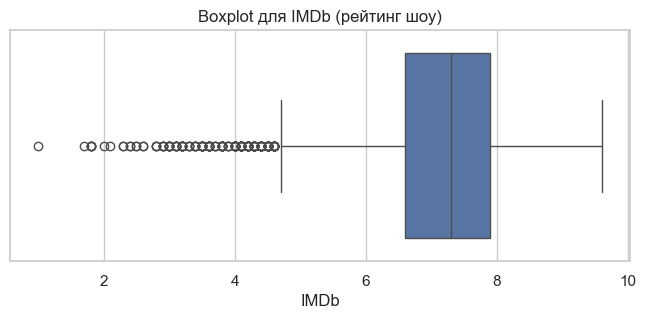

In [42]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["IMDb"])
plt.title("Boxplot для IMDb (рейтинг шоу)")
plt.xlabel("IMDb")
plt.show()

## 4. Разведочный анализ (Mini‑EDA)

Строим:
1) распределение ключевого числового признака (`IMDb`);  
2) распределение категориального признака (`Age`);  
3) зависимость между двумя признаками (`Year` и `IMDb`).

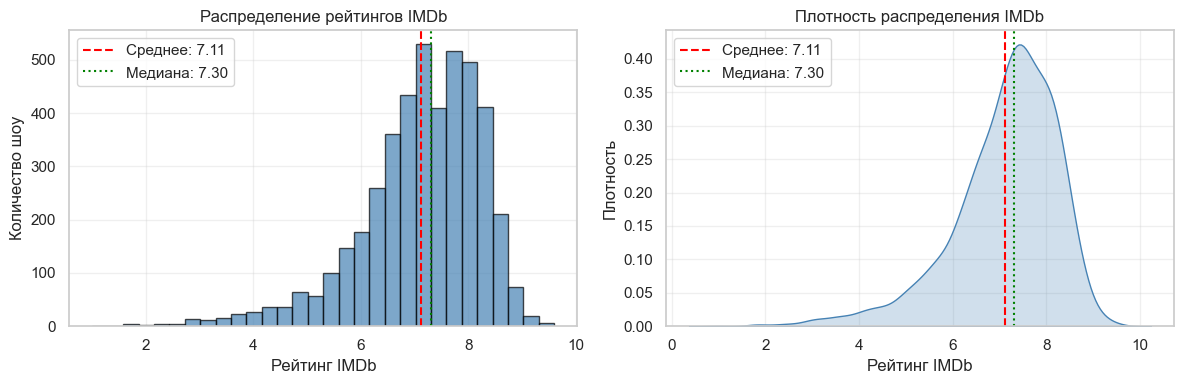

In [43]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(imdb_clean, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Распределение рейтингов IMDb')
plt.xlabel('Рейтинг IMDb')
plt.ylabel('Количество шоу')
plt.axvline(imdb_clean.mean(), color='red', linestyle='--', label=f'Среднее: {imdb_clean.mean():.2f}')
plt.axvline(imdb_clean.median(), color='green', linestyle=':', label=f'Медиана: {imdb_clean.median():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.kdeplot(imdb_clean, fill=True, color='steelblue')
plt.title('Плотность распределения IMDb')
plt.xlabel('Рейтинг IMDb')
plt.ylabel('Плотность')
plt.axvline(imdb_clean.mean(), color='red', linestyle='--', label=f'Среднее: {imdb_clean.mean():.2f}')
plt.axvline(imdb_clean.median(), color='green', linestyle=':', label=f'Медиана: {imdb_clean.median():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

По распределению видно, что большинство шоу имеют рейтинг от 6.5 до 8.5. Распределение немного смещено влево (левосторонняя асимметрия), есть длинный хвост низких рейтингов (выбросы).

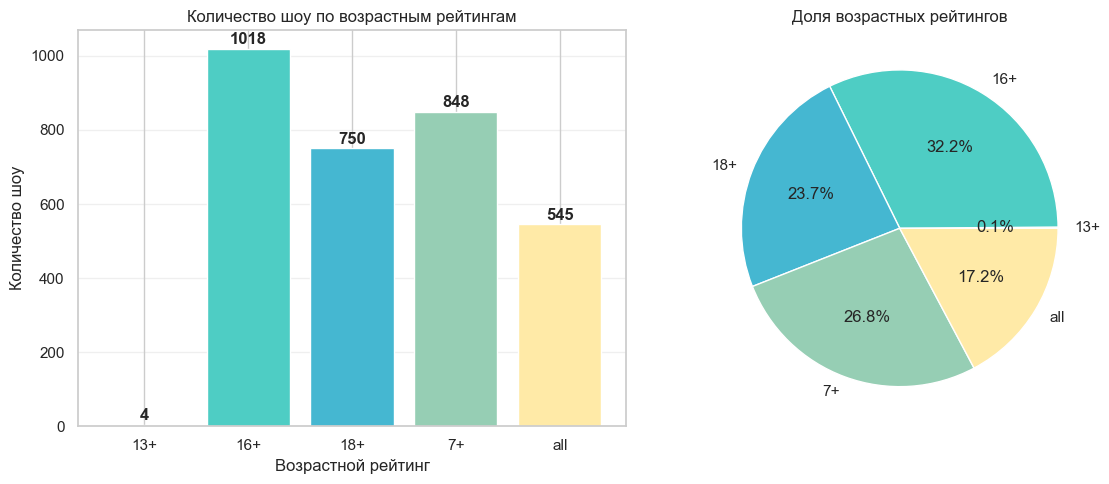

In [45]:
plt.figure(figsize=(12, 5))

# Убираем пропуски для визуализации
age_clean = df['Age'].dropna()

plt.subplot(1, 2, 1)
age_counts = age_clean.value_counts().sort_index()
bars = plt.bar(age_counts.index.astype(str), age_counts.values, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title('Количество шоу по возрастным рейтингам')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Количество шоу')
plt.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, age_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(value), 
             ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%',
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title('Доля возрастных рейтингов')

plt.tight_layout()
plt.show()

Частоты по возрастным рейтингам показывают, что самая популярная категория - шоу для 16+ (32.2%). Детские шоу (7+ и all) составляют около 44%, взрослые (18+) - 23.7%.

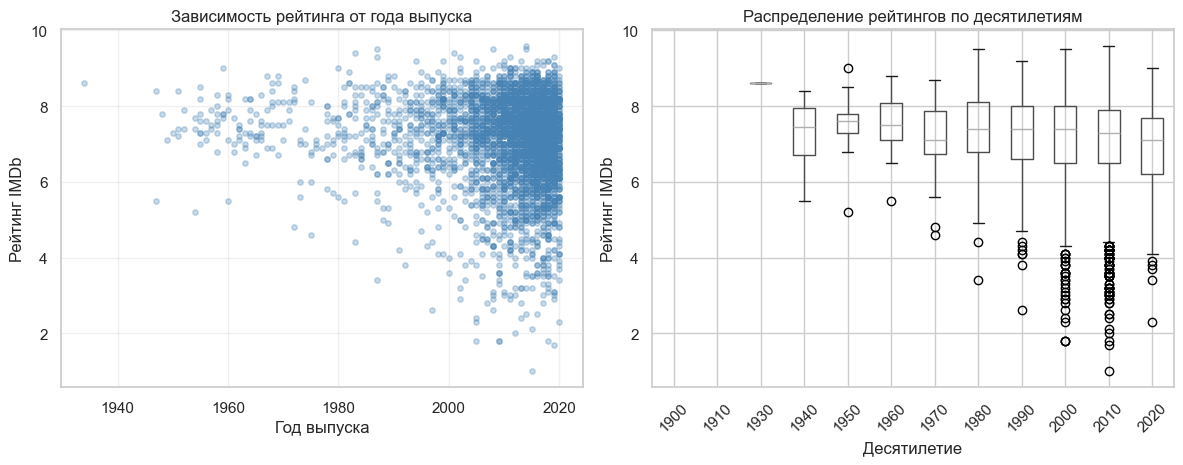

In [46]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['Year'], df['IMDb'], alpha=0.3, c='steelblue', s=15)
plt.title('Зависимость рейтинга от года выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Рейтинг IMDb')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
df['Decade'] = (df['Year'] // 10) * 10
df.boxplot(column='IMDb', by='Decade', ax=plt.gca())
plt.title('Распределение рейтингов по десятилетиям')
plt.suptitle('')
plt.xlabel('Десятилетие')
plt.ylabel('Рейтинг IMDb')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Графики показывают, что современные шоу (2000+) имеют больший разброс рейтингов. Классические шоу (1950-1990) в среднем имеют высокие рейтинги. После 2010 года появилось много шоу с низкими рейтингами, что увеличило разброс.